<a href="https://colab.research.google.com/github/Nikita-hub6377/Prodigy/blob/main/Image_To_Image_Translation_With_cGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

In [25]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype(np.float32) -127.5 / 127.5
x_test = np.expand_dims(x_train, axis=-1)


In [26]:
def build_generator():
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(inputs)
    x = layers.LeakyReLU()(x)
    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same')(x)
    outputs = layers.Activation('tanh')(x)
    return keras.Model(inputs, outputs)

def build_discriminator():
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(inputs)
    x = layers.LeakyReLU()(x)
    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs)

In [27]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [28]:
def train(epochs, batch_size):
    for epoch in range(epochs):
        for _ in range(x_train.shape[0] // batch_size):
            # Generate random noise
            noise = np.random.normal(0, 1, (batch_size, 28, 28, 1))
            generated_images = generator.predict(noise)

            # Create labels
            real_labels = np.ones((batch_size, 1))
            fake_labels = np.zeros((batch_size, 1))

            # Train the discriminator
            d_loss_real = discriminator.train_on_batch(x_train[np.random.randint(0, x_train.shape[0], batch_size)], real_labels)
            d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            # Train the generator
            g_loss = combined_model.train_on_batch(noise, real_labels)

        print(f"{epoch}/{epochs} [D loss: {d_loss[0]:.4f}, acc.: {100 * d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")

In [29]:
def build_discriminator():
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(inputs)
    x = layers.LeakyReLU()(x)
    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Flatten()(x)
    # Add a sigmoid activation to the output layer for binary classification
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

In [30]:
# Generate and visualize some images
def plot_generated_images(generator, n_images=10):
    pass

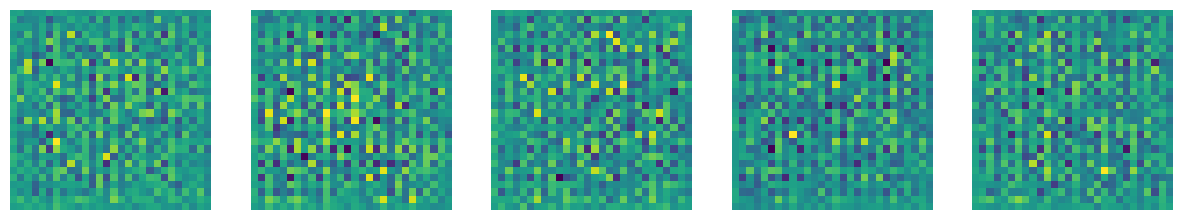

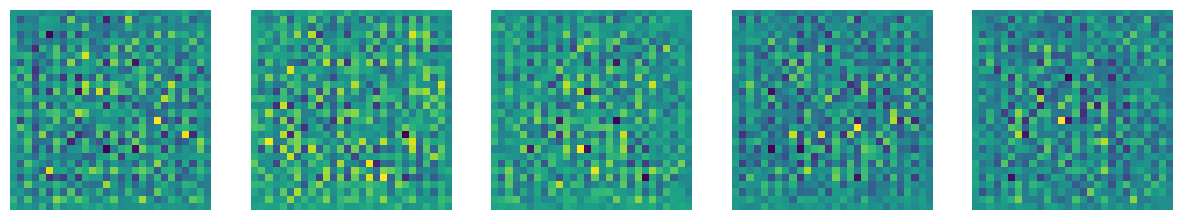

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate images
def generate_images(generator, test_input):
    # Generate images from the test input
    predictions = generator(test_input, training=False)
    return predictions

# Function to display generated images
def display_generated_images(generator, test_input, num_images=5):
    predictions = generate_images(generator, test_input)

    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow((predictions[i] + 1) / 2)  # Rescale to [0, 1]
        plt.axis('off')
    plt.show()

# Assuming 'generator' is your trained generator model and 'test_input' is your input data
# Change the shape of the test_input to match the expected input shape of the generator
test_input = np.random.normal(size=(5, 28, 28, 1))  # Example input with correct shape
display_generated_images(generator, test_input)

# Function to translate images
def translate_images(generator, input_images):
    translated_images = generator(input_images, training=False)
    return translated_images

# Example usage for translating images
# Change the shape of the input_images to match the expected input shape of the generator
input_images = np.random.normal(size=(5, 28, 28, 1))  # Replace with actual images with correct shape
translated_images = translate_images(generator, input_images)

# Display translated images
display_generated_images(generator, input_images)

In [32]:
batch_size = 32  # Define the batch size
input_images = np.random.normal(size=(batch_size, 28, 28, 1))  # Adjust dimensions if needed

In [33]:
translated_images = translate_images(generator, input_images)

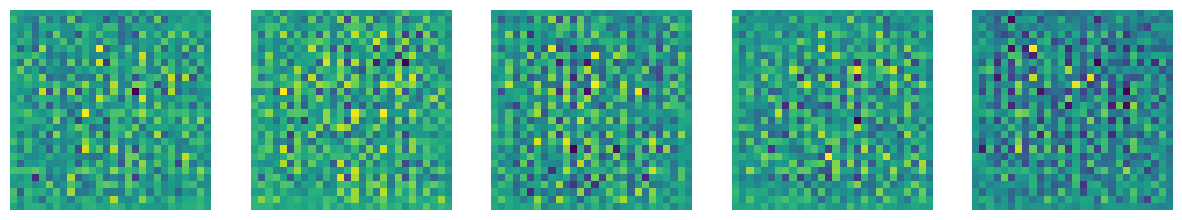

In [34]:
display_generated_images(generator, input_images)

In [35]:
print("Input images shape:", input_images.shape)
print("Translated images shape:", translated_images.shape)

Input images shape: (32, 28, 28, 1)
Translated images shape: (32, 28, 28, 1)
